In [134]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt

In [315]:
class LSTMCell(nn.Module):
    def __init__(self, demb, hidden_size):
        super().__init__()
        self.xh_to_z = nn.Linear(demb+hidden_size, hidden_size)
        self.xh_to_r = nn.Linear(demb+hidden_size, hidden_size)
        self.xh_to_hbar = nn.Linear(demb+hidden_size, hidden_size)
    
    def forward(self, xt, hprev):
        xh = torch.cat([xt, hprev], dim=1)
        r = F.sigmoid(self.xh_to_r(xh))
        hprev_reset = r * hprev

        xhr = torch.cat([xt, hprev_reset], dim=1)
        hbar = F.tanh(self.xh_to_hbar(xhr))

        z = F.sigmoid(self.xh_to_z(xh))
        ht = (1-z) * hprev + z * hbar
        return ht
    
class LSTMLayer(nn.Module):
    def __init__(self, emb1, emb2, hidden_layer, cell=LSTMCell):
        super().__init__()
        self.emb1 = emb1
        self.emb2 = emb2
        self.hidden_layer = hidden_layer

        rnns = []
        emb = [emb1] + [emb2]*hidden_layer
        for (_emb1, _emb2) in zip(emb[:hidden_layer], emb[1:]):
            # setattr(self, f"norm{i}", nn.LayerNorm(emb[i+1]))
            rnns.append(cell(demb=_emb1, hidden_size=_emb2))
        self.rnns = nn.ModuleList(rnns)
        self.dropout = nn.Dropout(0.5)
        self.start = nn.Parameter(torch.zeros(1, emb2))

    def forward(self, x, start=None):
        B, T, C = x.shape
        if start is None:
            hprev = self.start.expand((self.hidden_layer, B, -1))
        else: hprev = start.expand((self.hidden_layer, B, -1))
        hiddens_by_T = []

        def step(i, hprev):
            xt = x[:, i, :]
            hiddens = [] # (n_layer, B, H)
            prev_output = xt
            for i, rnn in enumerate(self.rnns):
                ht = rnn(prev_output, hprev[i])
                hiddens.append(ht)
                prev_output = self.dropout(ht) # regularization on LSTM!
            return hiddens
        
        for i in range(T):
            hiddens = step(i, hprev)
            hprev = hiddens
            hiddens_by_T.append(torch.stack(hiddens, dim=0)) # (N B H)
        hiddens_by_T = torch.stack(hiddens_by_T, 1).transpose(1, 2) # (N T B H) -> (N B T H)
        return hiddens_by_T

In [809]:
start = "<s>"
end = "</s>"
token_map = {"<s>": 0, "</s>": 1}

n_data = 1000


x = torch.rand((n_data, N))
x = (x-x.mean()) / x.std()
# print(torch.tensor([[[5]]*n_data]))
y_by_arg = torch.cat([x.argsort(dim=-1), torch.tensor([5]).expand(n_data, 1)], dim=-1)
x = x.unsqueeze(-1)
y = x.sort(dim=-1).values


In [810]:
class DS(Dataset):
    def __init__(self, n_data, N=5):
        super().__init__()
        x = torch.rand((n_data, N))
        self.y_by_arg = torch.cat([x.argsort(dim=-1), torch.tensor([5]).expand(n_data, 1)], dim=-1)
        self.x = x.unsqueeze(-1)
        self.y = self.x.sort(dim=-2).values
        self.n_data = n_data
    def __len__(self): return self.n_data
    def __getitem__(self, i): return (self.x[i], self.y[i], self.y_by_arg[i])

In [832]:
N = 5
train_data = DataLoader(DS(10000, N), batch_size=128, shuffle=False)
test_data = DataLoader(DS(100, N), batch_size=100, shuffle=False)

In [833]:
demb = 15
n_layers = 3
# model = LSTMLayer(1, demb, 10)
model = nn.GRU(1, demb, n_layers, bias=True, batch_first=True, dropout=0.2)
start_h = torch.zeros((1, demb), requires_grad=True)
loss_fn = nn.CrossEntropyLoss()
W1 = torch.empty((demb, demb), requires_grad=True)
b1 = torch.zeros((demb), requires_grad=True)
W2 = torch.empty((demb, demb), requires_grad=True)
b2 = torch.zeros((demb), requires_grad=True)
bound = 1/math.sqrt(demb)
torch.nn.init.uniform_(W1, a=-bound, b=bound)
torch.nn.init.uniform_(W2, a=-bound, b=bound)
start = torch.tensor([-1], requires_grad=True)

RuntimeError: Only Tensors of floating point and complex dtype can require gradients

In [834]:
def forward(x, N):
    B = x.shape[0]
    # hiddens_by_T = model(x, start_h)
    # hiddens_on_last = hiddens_by_T[-1]
    # hiddens_on_last, _ = model(x, hx=start_h.expand((n_layers, B, -1)))
    hiddens_on_last, _ = model(x, hx=start_h.expand((n_layers, B, -1)))
    enc_hidden = torch.cat([hiddens_on_last[:, :N], start_h.expand((B, 1, -1))], dim=1) # N+1
    dec_hidden = hiddens_on_last[:, N:] # N+1
    e = enc_hidden @ W1
    d = dec_hidden @ W2

    sim = d @ e.transpose(-1, -2) / math.sqrt(N)

    return sim

def train(x, y, y_by_arg, N=5):
    B = x.shape[0]
    xy = torch.cat([x, start.expand((B, 1, 1)), y], dim=1) 
    sim = forward(xy, N)

    loss = loss_fn(sim.view(-1, N+1), y_by_arg.view(-1))
    return loss, sim

@torch.no_grad()
def test(x, N=5):
    B = x.shape[0]
    x = torch.cat([x, start.expand((B, 1, 1))], dim=1)
    mask = torch.zeros((B, N+1))
    sorted_idx = []
    model.eval()
    for _ in range(N+1):
        sim = forward(x, N)[:, -1]
        sim = sim.masked_fill(mask.bool(), float("-inf"))
        idx = torch.argmax(sim, dim=-1, keepdim=True)
        sorted_idx.append(idx)
        mask = mask.clone()
        mask = mask.scatter(-1, idx, 1)
        gathered = torch.gather(x, dim=1, index=idx.unsqueeze(-1).expand(-1, -1, x.size(-1)))
        x = torch.cat([x, gathered], dim=-2)
    # plt.imshow(F.softmax(forward(x[:, :-1])[0]).detach(), cmap="gray")
    model.train()
    return torch.cat(sorted_idx, 1)

# test(x[:3])

In [835]:
optimizer = torch.optim.Adam(list(model.parameters())+[W1, W2, start_h], lr=0.001)

n_epoch = 100
test_sample = next(iter(test_data))

history = []

for i in range(n_epoch):
    for sample in train_data:
        loss, sim = train(*sample, N=N)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    # if i % 10 == 0:
    #     plt.imshow(F.softmax(sim[0], dim=-1).detach(), cmap="gray")
    #     plt.show()
    x, y, y_by_arg = test_sample
    flattened_pred = test(x, N=N).view(-1)
    is_right = (flattened_pred == y_by_arg.view(-1)).view(-1, N+1).sum(-1) == N+1
    accuracy = is_right.sum() / x.shape[0]
    history.append(accuracy)
    print(f"train {loss.item()=}, test {accuracy.item()=}")

train loss.item()=1.537531852722168, test accuracy.item()=0.0
train loss.item()=1.411137580871582, test accuracy.item()=0.009999999776482582
train loss.item()=1.3617693185806274, test accuracy.item()=0.019999999552965164
train loss.item()=1.3397866487503052, test accuracy.item()=0.05999999865889549
train loss.item()=1.3404923677444458, test accuracy.item()=0.18000000715255737
train loss.item()=1.3240946531295776, test accuracy.item()=0.5199999809265137
train loss.item()=1.0608757734298706, test accuracy.item()=0.07999999821186066
train loss.item()=0.9005736708641052, test accuracy.item()=0.20999999344348907
train loss.item()=0.7537398934364319, test accuracy.item()=0.27000001072883606
train loss.item()=0.7316847443580627, test accuracy.item()=0.3799999952316284
train loss.item()=0.6397197246551514, test accuracy.item()=0.41999998688697815
train loss.item()=0.6779699325561523, test accuracy.item()=0.4099999964237213
train loss.item()=0.7320119738578796, test accuracy.item()=0.4300000071

Text(0, 0.5, 'acc')

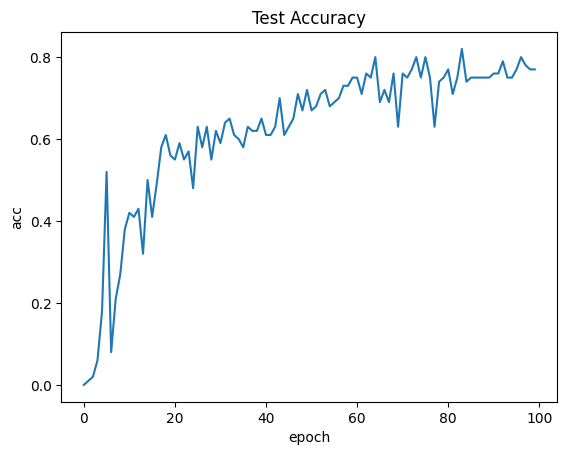

In [836]:
plt.title("Test Accuracy")
plt.plot(range(n_epoch), history)
plt.xlabel("epoch")
plt.ylabel("acc")

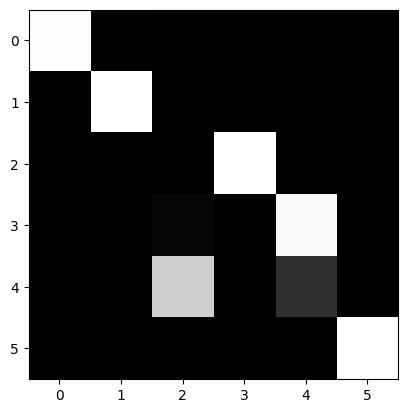

In [837]:
plt.imshow(F.softmax(sim[0], dim=-1).detach(), cmap="gray")

In [838]:
sim[0]

tensor([[ 59.3629,  53.9174, -14.5453,  34.0666,  -2.6876, -33.2534],
        [ 46.4059,  52.5437,  -0.7121,  42.8047,  12.0433, -29.6080],
        [ 14.7970,  36.6523,  20.3324,  44.5888,  30.9732, -16.3084],
        [-23.6242,   4.4784,  32.6332,  26.6623,  36.2811,   4.1203],
        [-36.1668, -14.5632,  27.8735,   7.5894,  26.4572,  13.7332],
        [-44.6351, -38.6095,  12.2838, -22.9760,   3.7998,  23.9701]],
       grad_fn=<SelectBackward0>)

In [839]:
test(x[:3])

tensor([[4, 1, 3, 2, 0, 5],
        [1, 2, 0, 4, 3, 5],
        [0, 4, 1, 3, 2, 5]])

In [840]:
y_by_arg[:3]

tensor([[1, 4, 3, 2, 0, 5],
        [1, 2, 0, 3, 4, 5],
        [0, 4, 1, 3, 2, 5]])

In [841]:
is_right

tensor([False, False,  True,  True,  True,  True, False,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True, False,  True,  True,
        False, False,  True,  True, False,  True,  True,  True,  True, False,
         True, False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True, False, False,  True, False,
         True,  True,  True, False,  True,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True, False,  True,  True,  True,  True,
         True, False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True, False,  True,  True,  True,  True,  True, False,
         True,  True,  True,  True, False, False,  True,  True, False,  True])

In [842]:
torch.argwhere(is_right==0).view(-1)

tensor([ 0,  1,  6,  8, 17, 20, 21, 24, 29, 31, 32, 46, 47, 49, 53, 58, 65, 71,
        83, 89, 94, 95, 98])

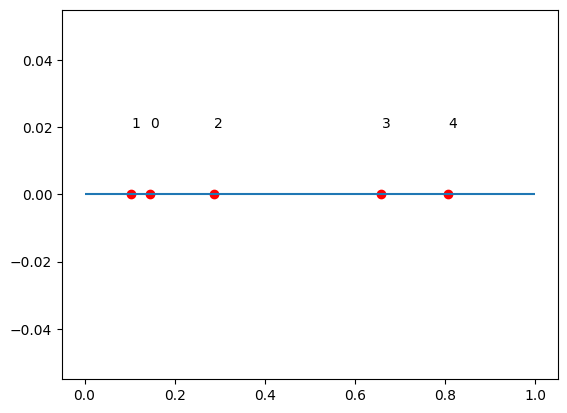

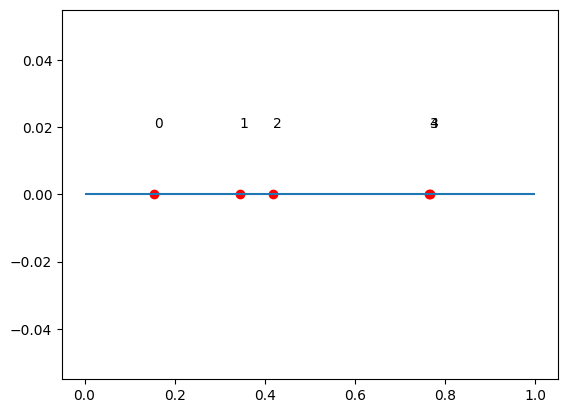

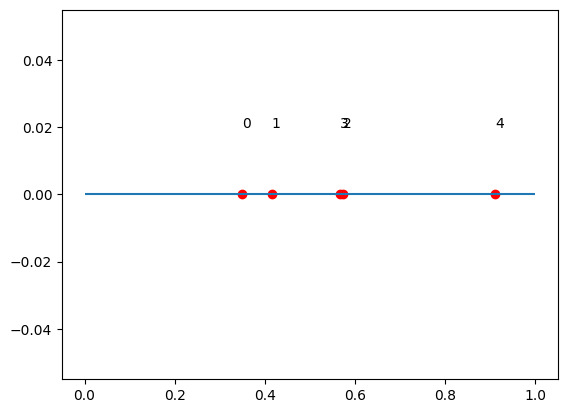

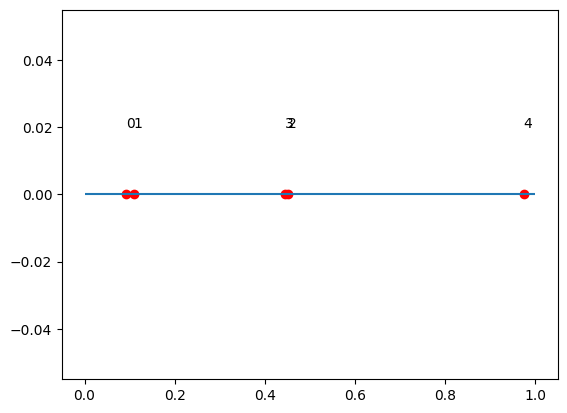

In [843]:
import numpy as np

x, _, _ = test_sample
pred = test(x, N)

def number_line(points, ranks):
    # x, yy, y = test_sample
    # points = x[i]
    # print(pred[i], y[i])
    rank_map = {i: rank for rank, i in enumerate(ranks.tolist())}
    plt.hlines(0, 0, 1)
    plt.scatter(points, [0] * len(points), c="r")
    for i, point in enumerate(points):
        plt.text(point, 0.02, str(rank_map[i]))
    plt.show()

def number_line_test(i):
    return number_line(x[i], pred[i])

for i in torch.argwhere(is_right==0).view(-1)[:4]:
    number_line_test(i)

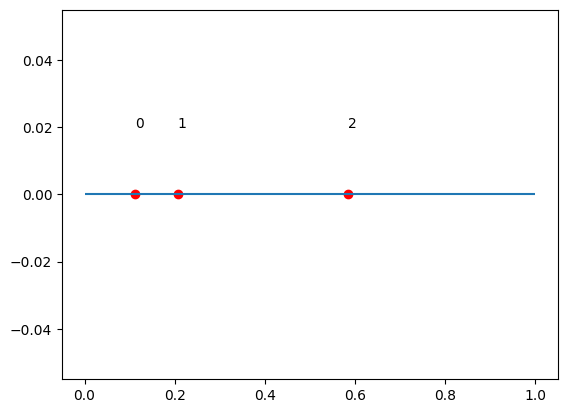

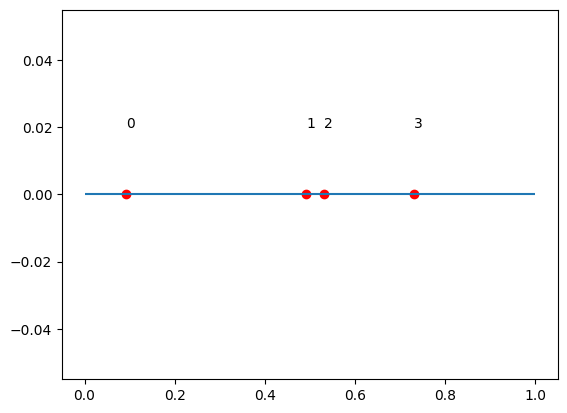

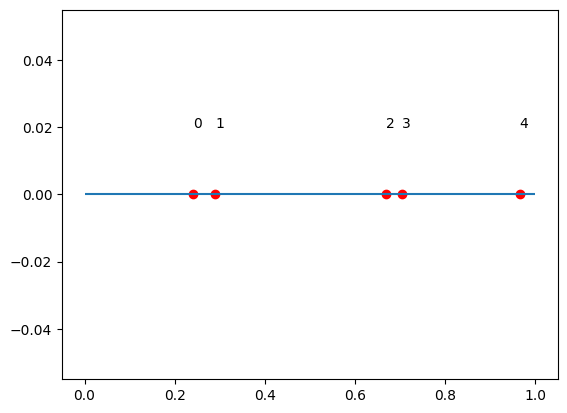

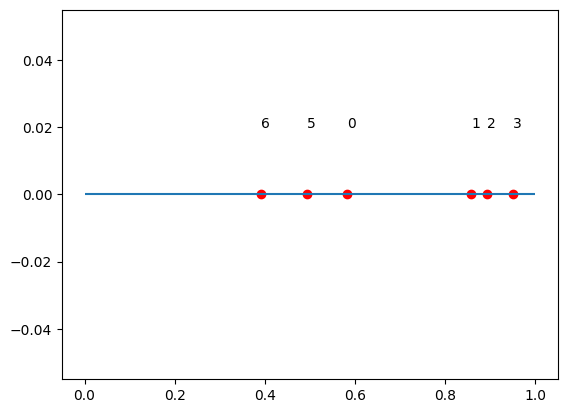

In [844]:
for new_N in range(3, 7):
    # new_N = 5

    new_test = DS(100, new_N)
    new_test_x, _, new_test_y = new_test[0]
    new_test_x = new_test_x.unsqueeze(0)

    flattened_pred = test(new_test_x, new_N).view(-1)

    is_right = (flattened_pred == new_test_y.view(-1)).view(-1, new_N+1).sum(-1) == new_N+1
    accuracy = is_right.sum() / x.shape[0]

    number_line(new_test_x[0], flattened_pred)